# Analista de Planeación e Inteligencia de Negocios - Chacutería Foods

## Análisis Exploratorio de Datos (EDA) y Consolidación

Este notebook contiene todas las etapas necesarias para preparar y consolidar los datos transaccionales, de presupuesto y de mercado (Nielsen) solicitados en la prueba técnica.

### 1. Carga de Librerías y Fuentes de Datos

![alt text](<imagenes/Client Product Sell-In Flow-2026-03-13-190624.png>)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Configuración del entorno
pd.set_option('display.max_columns', None)
data_path = 'paquete_candidato_chacuteria_foods/'

In [2]:
# Carga de Maestros
maestro_productos = pd.read_csv(f'{data_path}Maestro_productos.csv') # infomacion especifica de cada producto, se ignora la primera fila y se usa la segunda como nombre de columna
maestro_clientes = pd.read_csv(f'{data_path}Maestro_clientes.csv') # infomacion especifica de cada cliente, se ignora la primera fila y se usa la segunda como nombre de columna


# Carga de Inventario Inicial, Presupuesto y Mercado
inventario_inicial = pd.read_csv(f'{data_path}Inventario_cliente_inicial.csv')
mercado = pd.read_csv(f'{data_path}Mercado_Nielsen_simulado.csv')

In [3]:
presupuesto = pd.read_csv(f'{data_path}Presupuesto_ventas.csv')

def Estandarizar_nombres_presupuesto(df_pres, df_clientes):
    # Eliminar columna 'canal'
    if 'canal' in df_pres.columns:
        df_pres = df_pres.drop(columns=['canal'])
    
    # Crear diccionario cliente -> cliente_id usando maestro_clientes
    dict_clientes = dict(zip(df_clientes['cliente'], df_clientes['cliente_id']))
    
    # Reemplazar la columna cliente por cliente_id
    if 'cliente' in df_pres.columns:
        df_pres['cliente'] = df_pres['cliente'].map(dict_clientes)
        df_pres = df_pres.rename(columns={'cliente': 'cliente_id'})
        
    return df_pres

presupuesto = Estandarizar_nombres_presupuesto(presupuesto, maestro_clientes)



In [4]:
def Estandarizar_nombres_Sell_in(data_path, maestro_clientes):
    import difflib
    mc = maestro_clientes.copy()
    mc['cliente_limpio'] = mc['cliente'].astype(str).str.lower().str.replace(' ', '', regex=False)
    # Temporalmente pasamos cadenauno a cadena para el mapeo
    mc['cliente_limpio'] = mc['cliente_limpio'].str.replace('cadenauno', 'cadena', regex=False)
    
    dict_clientes = dict(zip(mc['cliente_limpio'], mc['cliente_id']))
    nombres_reales = list(dict_clientes.keys())
    
    def limpiar_y_mapear_cliente(serie):
        # limpiamos la columna destino
        s_limpio = serie.astype(str).str.lower().str.replace(' ', '', regex=False)
        s_limpio = s_limpio.str.replace('cadena1', 'cadena', regex=False)
        
        def encontrar_match(val):
            if pd.isna(val): return val
            if val.startswith('c0') and len(val) <= 4:
                return val.upper()
            if val in dict_clientes:
                return dict_clientes[val]
            # Búsqueda por substring (ej: "canastafamiliar" en "canastafamiliarsas")
            for real in nombres_reales:
                if real in val or val in real:
                    return dict_clientes[real]
            # Búsqueda difusa para errores de tipeo o abreviaciones
            matches = difflib.get_close_matches(val, nombres_reales, n=1, cutoff=0.65)
            if matches:
                return dict_clientes[matches[0]]
            return None
            
        serie_mapeada = s_limpio.apply(encontrar_match)
        # Reemplazos por si no mapeó
        serie_original_ajustada = serie.replace({'Cadena 1': 'Cadena Uno'})
        return serie_mapeada.fillna(serie_original_ajustada)

    # 1) Sell_in_1
    df1 = pd.read_csv(f'{data_path}Sell_in_1.csv')
    df1 = df1.rename(columns={'cliente': 'cliente_id', 'sku': 'sku', 'unidades': 'unidades_vendidas', 'kilos': 'kilos_vendidos'})
    df1['cliente_id'] = limpiar_y_mapear_cliente(df1['cliente_id'])
    df1['fecha_factura'] = pd.to_datetime(df1['fecha_factura'], format='%d/%m/%Y', errors='coerce')
    df1['trimestre'] = 1
    if 'comentario' not in df1.columns: df1['comentario'] = 'N/A'
    
    # 2) Sell_in_2
    df2 = pd.read_csv(f'{data_path}Sell_in_2.csv')
    df2 = df2.rename(columns={'fecha_mov': 'fecha_factura', 'SKU': 'sku', 'unidades_vta':'unidades_vendidas','kg_vta': 'kilos_vendidos', 'venta_neta': 'valor_venta', 'ejecutivo': 'responsable_comercial'})
    df2['cliente_id'] = limpiar_y_mapear_cliente(df2['cliente_id'])
    df2['fecha_factura'] = pd.to_datetime(df2['fecha_factura'], format='%m-%d-%Y', errors='coerce')
    df2['trimestre'] = 2
    if 'archivo_origen' not in df2.columns: df2['archivo_origen'] = 'N/A'
    
    # 3) Sell_in_3
    df3 = pd.read_csv(f'{data_path}Sell_in_3.csv')
    df3 = df3.rename(columns={'Fecha': 'fecha_factura', 'Cod_Cliente': 'cliente_id', 'sku_producto': 'sku', 'unidades': 'unidades_vendidas', 'vr_venta': 'valor_venta', 'asesor': 'responsable_comercial', 'estado_registro': 'comentario'})
    df3['cliente_id'] = limpiar_y_mapear_cliente(df3['cliente_id'])
    df3['fecha_factura'] = pd.to_datetime(df3['fecha_factura'], format='%Y/%m/%d', errors='coerce')
    df3['trimestre'] = 3
    if 'archivo_origen' not in df3.columns: df3['archivo_origen'] = 'N/A'
    
    columnas_finales = ['fecha_factura', 'trimestre', 'cliente_id', 'sku', 'unidades_vendidas', 'kilos_vendidos', 'valor_venta', 'responsable_comercial', 'comentario', 'archivo_origen']
    consolidado = pd.concat([df1, df2, df3], ignore_index=True)
    consolidado['sku'] = consolidado['sku'].astype(str).str.replace(r'(?i)SKU[-_ ]?', '', regex=True)
    consolidado['sku'] = pd.to_numeric(consolidado['sku'], errors='coerce')
    
    for col in columnas_finales:
        if col not in consolidado.columns: consolidado[col] = pd.NA
            
    consolidado = consolidado[columnas_finales]
    consolidado['fecha_factura'] = pd.to_datetime(consolidado['fecha_factura'], errors='coerce').dt.strftime('%d/%m/%Y')
    consolidado = consolidado.fillna('N/A')
    
    return consolidado

Consolidado_sell_in = Estandarizar_nombres_Sell_in(data_path, maestro_clientes)







In [5]:
Consolidado_sell_in["cliente_id"].unique()

array(['C017', 'C015', 'C014', 'C003', 'C016', 'C001', 'C002', 'C004',
       'C018', 'C008', 'C009', 'C005', 'C006', 'C007', 'C013', 'C012',
       'C011', 'C010'], dtype=object)

In [6]:
Consolidado_sell_in

,fecha_factura,trimestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,valor_venta,responsable_comercial,comentario,archivo_origen
0,01/01/2025,1,C017,900101,2,0.16,15270,Daniel Rojas,N/A,ERP_COMERCIAL_Q1
1,01/01/2025,1,C017,110108,2,0.3,23540,Laura Mejía,N/A,ERP_COMERCIAL_Q1
2,01/01/2025,1,C017,900103,3,0.24,24940,Laura Mejía,N/A,ERP_COMERCIAL_Q1
3,03/01/2025,1,C017,110113,2,0.5,23820,Laura Mejía,N/A,ERP_COMERCIAL_Q1
4,03/01/2025,1,C017,300102,3,N/A,22130,Daniel Rojas,N/A,ERP_COMERCIAL_Q1
...,...,...,...,...,...,...,...,...,...,...
8045,22/12/2025,3,C017,900103,4,0.32,33670,Daniel Rojas,OK,N/A
8046,02/12/2025,3,C018,130101,335,N/A,1369880,María Paz Torres,OK,N/A
8047,14/11/2025,3,C018,120101,144,36.0,1061880,María Paz Torres,OK,N/A
8048,14/10/2025,3,C013,199902,6,1.8,98000,María Paz Torres,REVISAR,N/A


In [7]:
Consolidado_sell_in[Consolidado_sell_in["kilos_vendidos"]=="N/A"]

,fecha_factura,trimestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,valor_venta,responsable_comercial,comentario,archivo_origen
4,03/01/2025,1,C017,300102,3,N/A,22130,Daniel Rojas,N/A,ERP_COMERCIAL_Q1
228,15/01/2025,1,C017,900102,3,N/A,22550,Laura Mejía,N/A,ERP_COMERCIAL_Q1
304,20/01/2025,1,C001,900103,72,N/A,592340,Laura Mejía,N/A,ERP_COMERCIAL_Q1
499,27/01/2025,1,C016,120104,64,N/A,392740,Juan Sebastián León,N/A,ERP_COMERCIAL_Q1
527,29/01/2025,1,C012,110102,20,N/A,223820,Laura Mejía,N/A,ERP_COMERCIAL_Q1
...,...,...,...,...,...,...,...,...,...,...
7381,04/12/2025,3,C014,110105,66,N/A,740550,María Paz Torres,OK,N/A
7549,11/12/2025,3,C001,110106,68,N/A,671060,Daniel Rojas,OK,N/A
7890,25/12/2025,3,C016,110102,43,N/A,472400,Juan Sebastián León,OK,N/A
8010,31/12/2025,3,C013,190101,4,N/A,78820,María Paz Torres,OK,N/A


In [8]:
# 
# Eliminado consolidado residual
def Estandarizar_nombres_Sell_out(data_path, maestro_clientes):
    import difflib
    # Crear diccionario de mapeo con nombres limpios
    mc = maestro_clientes.copy()
    mc['cliente_limpio'] = mc['cliente'].astype(str).str.lower().str.replace(' ', '', regex=False)
    mc['cliente_limpio'] = mc['cliente_limpio'].str.replace('cadenauno', 'cadena', regex=False)
    
    dict_clientes = dict(zip(mc['cliente_limpio'], mc['cliente_id']))
    nombres_reales = list(dict_clientes.keys())
    
    def limpiar_y_mapear_cliente(serie):
        s_limpio = serie.astype(str).str.lower().str.replace(' ', '', regex=False)
        s_limpio = s_limpio.str.replace('cadena1', 'cadena', regex=False)
        
        def encontrar_match(val):
            if pd.isna(val): return val
            if val.startswith('c0') and len(val) <= 4:
                return val.upper()
            if val in dict_clientes:
                return dict_clientes[val]
            for real in nombres_reales:
                if real in val or val in real:
                    return dict_clientes[real]
            matches = difflib.get_close_matches(val, nombres_reales, n=1, cutoff=0.65)
            if matches:
                return dict_clientes[matches[0]]
            return None
            
        serie_mapeada = s_limpio.apply(encontrar_match)
        serie_original_ajustada = serie.replace({'Cadena 1': 'Cadena Uno'})
        return serie_mapeada.fillna(serie_original_ajustada)

    # 1) Sell_out_1
    df1 = pd.read_csv(f'{data_path}Sell_out_1.csv')
    df1 = df1.rename(columns={
        'fecha_pv': 'fecha_factura', 
        'cliente': 'cliente_id', 
        'sku': 'sku', 
        'und_vendidas': 'unidades_vendidas', 
        'kg_vendidos': 'kilos_vendidos', 
        'valor_sellout': 'valor_venta',
        'fuente': 'archivo_origen'
    })
    df1['cliente_id'] = limpiar_y_mapear_cliente(df1['cliente_id'])
    df1['fecha_factura'] = pd.to_datetime(df1['fecha_factura'], format='%d-%m-%Y', errors='coerce')
    # Backup parsing in case of different format
    if df1['fecha_factura'].isna().all(): df1['fecha_factura'] = pd.to_datetime(df1['fecha_factura'], format='%d-%m-%Y', errors='coerce')
    df1['semestre'] = 1
    
    # 2) Sell_out_2
    df2 = pd.read_csv(f'{data_path}Sell_out_2.csv')
    df2 = df2.rename(columns={
        'fecha': 'fecha_factura', 
        'cliente_id': 'cliente_id', 
        'producto_sku': 'sku', 
        'unidades_sell_out': 'unidades_vendidas', 
        'kilos_sell_out': 'kilos_vendidos', 
        'valor_sell_out': 'valor_venta',
        'archivo_origen': 'archivo_origen'
    })
    df2['cliente_id'] = limpiar_y_mapear_cliente(df2['cliente_id'])
    df2['fecha_factura'] = pd.to_datetime(df2['fecha_factura'], format='%Y-%m-%d', errors='coerce')
    df2['semestre'] = 2
    
    columnas_finales = ['fecha_factura', 'semestre', 'cliente_id', 'sku', 'unidades_vendidas', 'kilos_vendidos', 'valor_venta', 'archivo_origen']
    consolidado = pd.concat([df1, df2], ignore_index=True)
    consolidado['sku'] = consolidado['sku'].astype(str).str.replace(r'(?i)SKU[-_ ]?', '', regex=True)
    consolidado['sku'] = pd.to_numeric(consolidado['sku'], errors='coerce')
    
    for col in columnas_finales:
        if col not in consolidado.columns: consolidado[col] = pd.NA
            
    consolidado = consolidado[columnas_finales]
    consolidado['fecha_factura'] = pd.to_datetime(consolidado['fecha_factura'], errors='coerce').dt.strftime('%d/%m/%Y')
    consolidado = consolidado.fillna('N/A')
    
    return consolidado

Consolidado_sell_out = Estandarizar_nombres_Sell_out(data_path, maestro_clientes)




In [9]:
Consolidado_sell_out

,fecha_factura,semestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,valor_venta,archivo_origen
0,01/01/2025,1,C001,110101,3,0.45,44890,POS_SHARE_H1
1,02/01/2025,1,C001,110101,8,1.2,114190,POS_SHARE_H1
2,03/01/2025,1,C001,110101,5,0.75,74650,POS_SHARE_H1
3,04/01/2025,1,C001,110101,10,1.5,146700,POS_SHARE_H1
4,05/01/2025,1,C001,110101,8,1.2,115750,POS_SHARE_H1
...,...,...,...,...,...,...,...,...
64896,16/09/2025,2,C001,130101,8,1.2,46610,POS_SHARE_H2
64897,15/08/2025,2,C015,300101,1,0.23,8590,POS_SHARE_H2
64898,17/10/2025,2,C014,120101,18,4.5,185760,POS_SHARE_H2
64899,18/10/2025,2,C012,199902,3,0.9,56000,POS_SHARE_H2


In [10]:
Consolidado_sell_out[Consolidado_sell_out["kilos_vendidos"]=="N/A"]

,fecha_factura,semestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,valor_venta,archivo_origen
66,08/03/2025,1,C001,110101,7,N/A,101490,POS_SHARE_H1
162,12/06/2025,1,C001,110101,4,N/A,57790,POS_SHARE_H1
173,23/06/2025,1,C001,110101,2,N/A,28710,POS_SHARE_H1
217,06/02/2025,1,C001,110102,10,N/A,146940,POS_SHARE_H1
252,14/03/2025,1,C001,110102,12,N/A,173820,POS_SHARE_H1
...,...,...,...,...,...,...,...,...
64447,29/10/2025,2,C018,300101,5,N/A,40920,POS_SHARE_H2
64475,26/11/2025,2,C018,300101,6,N/A,49070,POS_SHARE_H2
64503,24/12/2025,2,C018,300101,13,N/A,106620,POS_SHARE_H2
64596,24/09/2025,2,C018,300102,6,N/A,51470,POS_SHARE_H2


In [11]:
import pandas as pd

def calcular_kilos(df, maestro_productos):
    # Hacemos una copia para no alterar el original a la fuerza
    df_calc = df.copy()
    
    # Diccionario de SKUs y sus pesos en KG
    dict_pesos = dict(zip(maestro_productos['sku'], maestro_productos['peso_kg']))
    
    # Mapear el peso_kg al dataframe consolidado
    pesos = df_calc['sku'].map(dict_pesos)
    
    # Calcular kilos numéricamente (evitando N/A strings temporalmente si los hubiera)
    unidades = pd.to_numeric(df_calc['unidades_vendidas'], errors='coerce')
    pesos_num = pd.to_numeric(pesos, errors='coerce')
    
    # Multiplicar peso_kg * unidades
    kilos_calculados = (unidades * pesos_num).round(2)
    
    # Insertar la columna calculada justo después de kilos_vendidos si existe
    if 'kilos_vendidos' in df_calc.columns:
        pos = df_calc.columns.get_loc('kilos_vendidos') + 1
        if 'kilos_vendidos_calculados' in df_calc.columns:
            df_calc = df_calc.drop(columns=['kilos_vendidos_calculados'])
        df_calc.insert(pos, 'kilos_vendidos_calculados', kilos_calculados)
    else:
        df_calc['kilos_vendidos_calculados'] = kilos_calculados
        
    # Rellenar con N/A visuales para los NaN generados si lo deseamos o dejarlo vacio
    df_calc['kilos_vendidos_calculados'] = df_calc['kilos_vendidos_calculados'].fillna('N/A')
    
    return df_calc

# Aplicamos la nueva función a los dos consolidados:
Consolidado_sell_in = calcular_kilos(Consolidado_sell_in, maestro_productos)
Consolidado_sell_out = calcular_kilos(Consolidado_sell_out, maestro_productos)

# Visualizar una prueba:
display(Consolidado_sell_in[['sku', 'unidades_vendidas', 'kilos_vendidos', 'kilos_vendidos_calculados']].head())
display(Consolidado_sell_out[['sku', 'unidades_vendidas', 'kilos_vendidos', 'kilos_vendidos_calculados']].head())



,sku,unidades_vendidas,kilos_vendidos,kilos_vendidos_calculados
0,900101,2,0.16,0.16
1,110108,2,0.3,0.3
2,900103,3,0.24,0.24
3,110113,2,0.5,0.5
4,300102,3,N/A,0.69


,sku,unidades_vendidas,kilos_vendidos,kilos_vendidos_calculados
0,110101,3,0.45,0.45
1,110101,8,1.2,1.2
2,110101,5,0.75,0.75
3,110101,10,1.5,1.5
4,110101,8,1.2,1.2


In [12]:
Consolidado_sell_in[Consolidado_sell_in["kilos_vendidos_calculados"]=="N/A"]

,fecha_factura,trimestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,kilos_vendidos_calculados,valor_venta,responsable_comercial,comentario,archivo_origen
2496,18/03/2025,1,C001,199901,12,3.6,N/A,184000,Laura Mejía,N/A,ERP_COMERCIAL_Q1
2497,25/04/2025,1,C002,199901,8,2.4,N/A,122000,Sara Vélez,N/A,ERP_COMERCIAL_Q1
8048,14/10/2025,3,C013,199902,6,1.8,N/A,98000,María Paz Torres,REVISAR,N/A
8049,22/11/2025,3,C017,199902,4,1.2,N/A,65000,Daniel Rojas,REVISAR,N/A


In [13]:
Consolidado_sell_out[Consolidado_sell_out["kilos_vendidos_calculados"]=="N/A"]

,fecha_factura,semestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,kilos_vendidos_calculados,valor_venta,archivo_origen
31433,27/06/2025,1,C015,199901,5,1.5,N/A,91000,POS_SHARE_H1
64899,18/10/2025,2,C012,199902,3,0.9,N/A,56000,POS_SHARE_H2


Notando que son pocos datos con el sku desconocido desido eliminarlos

In [14]:
Consolidado_sell_in = Consolidado_sell_in[~Consolidado_sell_in['sku'].isin([199901, 199902])]
Consolidado_sell_out = Consolidado_sell_out[~Consolidado_sell_out['sku'].isin([199901, 199902])]

![alt text](<imagenes/Client Product Sell-In Flow-2026-03-13-190158.png>)

### 2. Análisis de Calidad de Datos (Data Quality)

#### 2.1 Resumen Estadístico
A continuación generamos las estadísticas descriptivas para ambos consolidados (Sell-in y Sell-out). Estas incluyen recuento, media, desviación estándar, mínimos, máximos y percentiles (cuartiles) de las variables numéricas.

In [15]:
import IPython.core.display_functions
len(Consolidado_sell_in[Consolidado_sell_in["responsable_comercial"]=="María Paz Torres"])

1844

In [16]:
print("--- Resumen Sell-in ---")
display(Consolidado_sell_in.describe(include='all'))

print("\n--- Resumen Sell-out ---")
display(Consolidado_sell_out.describe(include='all'))


--- Resumen Sell-in ---


,fecha_factura,trimestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,kilos_vendidos_calculados,valor_venta,responsable_comercial,comentario,archivo_origen
count,8046,8046.000000,8046,8046.000000,8046.000000,8046,8046.0,8.046000e+03,8046,8046,8046
unique,311,NaN,18,NaN,NaN,1128,1102.0,NaN,7,7,2
top,24/11/2025,NaN,C001,NaN,NaN,N/A,1.0,NaN,María Paz Torres,N/A,N/A
freq,82,NaN,785,NaN,NaN,120,71.0,NaN,1844,4516,5550
mean,NaN,2.056674,NaN,289779.305618,65.434004,NaN,NaN,7.658605e+05,NaN,NaN,NaN
std,NaN,0.820962,NaN,300891.569309,57.664267,NaN,NaN,1.054382e+06,NaN,NaN,NaN
min,NaN,1.000000,NaN,110101.000000,1.000000,NaN,NaN,1.292000e+04,NaN,NaN,NaN
25%,NaN,1.000000,NaN,110113.000000,22.000000,NaN,NaN,2.591925e+05,NaN,NaN,NaN
50%,NaN,2.000000,NaN,120104.000000,55.000000,NaN,NaN,4.765750e+05,NaN,NaN,NaN
75%,NaN,3.000000,NaN,300102.000000,86.000000,NaN,NaN,7.250600e+05,NaN,NaN,NaN



--- Resumen Sell-out ---


,fecha_factura,semestre,cliente_id,sku,unidades_vendidas,kilos_vendidos,kilos_vendidos_calculados,valor_venta,archivo_origen
count,64899,64899.000000,64899,64899.000000,64899.000000,64899.00,64899.00,6.489900e+04,64899
unique,365,NaN,13,NaN,NaN,281.00,190.00,NaN,2
top,20/12/2025,NaN,C001,NaN,NaN,0.75,0.75,NaN,POS_SHARE_H2
freq,204,NaN,8577,NaN,NaN,2564.00,2609.00,NaN,33466
mean,NaN,1.515663,NaN,279106.453135,6.810768,NaN,NaN,6.761129e+04,NaN
std,NaN,0.499758,NaN,296123.392824,6.110321,NaN,NaN,4.674711e+04,NaN
min,NaN,1.000000,NaN,110101.000000,1.000000,NaN,NaN,5.390000e+03,NaN
25%,NaN,1.000000,NaN,110112.000000,3.000000,NaN,NaN,3.246000e+04,NaN
50%,NaN,2.000000,NaN,120103.000000,5.000000,NaN,NaN,5.794000e+04,NaN
75%,NaN,2.000000,NaN,300101.000000,9.000000,NaN,NaN,9.052000e+04,NaN


In [17]:
print("--- Valores Nulos en Sell-in ---")
display(Consolidado_sell_in.isnull().sum())

print("\n--- Valores Nulos en Sell-out ---")
display(Consolidado_sell_out.isnull().sum())


--- Valores Nulos en Sell-in ---


fecha_factura                0
trimestre                    0
cliente_id                   0
sku                          0
unidades_vendidas            0
kilos_vendidos               0
kilos_vendidos_calculados    0
valor_venta                  0
responsable_comercial        0
comentario                   0
archivo_origen               0
dtype: int64


--- Valores Nulos en Sell-out ---


fecha_factura                0
semestre                     0
cliente_id                   0
sku                          0
unidades_vendidas            0
kilos_vendidos               0
kilos_vendidos_calculados    0
valor_venta                  0
archivo_origen               0
dtype: int64

**Recomendaciones para tu Interpretación:**
- **Estadísticas (`.describe`):** Fíjate muy bien en los Mínimos (`min`) y Máximos (`max`) de ventas. ¿Existen cantidades negativas o ceros que deban tratarse o representen devoluciones? ¿Es el máximo algo desmesurado que distorsione los promedios?
- **Nulos (NaNs):** Observa qué columnas tienen nulos. Si hay muchos nulos en cruces de identificadores (ej., descripciones de `cliente_id` vacías si es que cruzamos con el maestro, o kilos vacíos calculados), quiere decir que la data de entrada trajo huecos (tal vez fallas de Nielsen).

In [18]:
print("--- Resumen maestro clientes ---")
display(maestro_clientes.describe(include='all'))
print("--- Valores Nulos en maestro clientes ---")
display(maestro_clientes.isnull().sum())

--- Resumen maestro clientes ---


,cliente_id,cliente,canal,regional,zona,ciudad,formato_cliente
count,18,18,18,18,17,18,18
unique,18,18,7,6,7,8,9
top,C001,HiperMax Nacional,Grandes Superficies,Centro,Bogotá y Sabana,Bogotá,Discounter
freq,1,1,5,5,5,5,4


--- Valores Nulos en maestro clientes ---


cliente_id         0
cliente            0
canal              0
regional           0
zona               1
ciudad             0
formato_cliente    0
dtype: int64

In [19]:
maestro_clientes.loc[maestro_clientes["regional"] == "Occidente", "zona"] = "Valle del Cauca"


Viendo en la logia podemos imputar el faltabte con valle del cauda

In [20]:
print("--- Resumen maestro clientes ---")
display(maestro_productos.describe(include='all'))
print("--- Valores Nulos en maestro clientes ---")
display(maestro_productos.isnull().sum())

--- Resumen maestro clientes ---


,sku,descripcion_producto,peso_kg,unidad,variedad,subcategoria,categoria,tipo_producto,marca,origen
count,37.000000,37,37.000000,37,37,37,37,37,37,37
unique,NaN,37,NaN,2,23,15,6,2,9,3
top,NaN,GOUDA AHUMADO TAJADO LOMA DORADA 150G,NaN,UND,MIXTO QUESOS,BLOQUES,QUESOS MADURADOS,regular,LOMA DORADA,IMPORTADO
freq,NaN,1,NaN,29,4,6,17,34,7,20
mean,268483.594595,NaN,0.379135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,287811.672092,NaN,0.348377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,110101.000000,NaN,0.080000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,110110.000000,NaN,0.150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,120103.000000,NaN,0.230000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,300101.000000,NaN,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Valores Nulos en maestro clientes ---


sku                     0
descripcion_producto    0
peso_kg                 0
unidad                  0
variedad                0
subcategoria            0
categoria               0
tipo_producto           0
marca                   0
origen                  0
dtype: int64

In [21]:
print("--- Resumen maestro clientes ---")
display(inventario_inicial.describe(include='all'))
print("--- Valores Nulos en maestro clientes ---")
display(inventario_inicial.isnull().sum())

--- Resumen maestro clientes ---


,fecha_corte,cliente_id,sku,unidades_inventario,kilos_inventario
count,222,222,222.000000,222.000000,218.000000
unique,1,13,NaN,NaN,NaN
top,2024-12-31,C014,NaN,NaN,NaN
freq,222,27,NaN,NaN,NaN
mean,NaN,NaN,276861.418919,77.558559,14.705092
std,NaN,NaN,289581.415514,67.876676,14.182291
min,NaN,NaN,110101.000000,1.000000,0.240000
25%,NaN,NaN,110112.000000,21.250000,4.327500
50%,NaN,NaN,120104.000000,70.500000,11.280000
75%,NaN,NaN,300101.000000,103.500000,20.435000


--- Valores Nulos en maestro clientes ---


fecha_corte            0
cliente_id             0
sku                    0
unidades_inventario    0
kilos_inventario       4
dtype: int64

Podemos imputar los 4 falantes calculando los kilos con el sku y el # de 

In [22]:
def calcular_kilos(df, maestro_productos):
    # Hacemos una copia para no alterar el original a la fuerza
    df_calc = df.copy()
    
    # Diccionario de SKUs y sus pesos en KG
    dict_pesos = dict(zip(maestro_productos['sku'], maestro_productos['peso_kg']))
    
    # Mapear el peso_kg al dataframe consolidado
    pesos = df_calc['sku'].map(dict_pesos)
    
    # Calcular kilos numéricamente (evitando N/A strings temporalmente si los hubiera)
    unidades = pd.to_numeric(df_calc['unidades_inventario'], errors='coerce')
    pesos_num = pd.to_numeric(pesos, errors='coerce')
    
    # Multiplicar peso_kg * unidades
    kilos_calculados = (unidades * pesos_num).round(2)
    
    # Insertar la columna calculada justo después de kilos_vendidos si existe
    if 'kilos_vendidos' in df_calc.columns:
        pos = df_calc.columns.get_loc('kilos_vendidos') + 1
        if 'kilos_calculados' in df_calc.columns:
            df_calc = df_calc.drop(columns=['kilos_calculados'])
        df_calc.insert(pos, 'kilos_calculados', kilos_calculados)
    else:
        df_calc['kilos_calculados'] = kilos_calculados
        
    # Rellenar con N/A visuales para los NaN generados si lo deseamos o dejarlo vacio
    df_calc['kilos_calculados'] = df_calc['kilos_calculados'].fillna('N/A')
    
    return df_calc

In [23]:
# Aplicamos la nueva función a los dos consolidados:
inventario_inicial = calcular_kilos(inventario_inicial, maestro_productos)

# Visualizar una prueba:
display(inventario_inicial)

,fecha_corte,cliente_id,sku,unidades_inventario,kilos_inventario,kilos_calculados
0,2024-12-31,C001,110101,97,14.55,14.55
1,2024-12-31,C001,110102,87,13.05,13.05
2,2024-12-31,C001,110103,102,15.30,15.30
3,2024-12-31,C001,110104,84,12.60,12.60
4,2024-12-31,C001,110105,88,13.20,13.20
...,...,...,...,...,...,...
217,2024-12-31,C018,900102,93,7.44,7.44
218,2024-12-31,C017,300102,4,0.92,0.92
219,2024-12-31,C003,110112,120,12.00,12.00
220,2024-12-31,C002,900102,86,6.88,6.88


In [24]:
print("--- Resumen maestro clientes ---")
display(mercado.describe(include='all'))
print("--- Valores Nulos en maestro clientes ---")
display(mercado.isnull().sum())

--- Resumen maestro clientes ---


,mes,categoria,subcategoria,canal,ventas_mercado_valor,ventas_mercado_volumen,share_compania,share_competidor_1,share_competidor_2
count,508,508,508,508,5.080000e+02,508.000000,508.000000,508.000000,508.000000
unique,12,6,13,5,NaN,NaN,NaN,NaN,NaN
top,2025-01,QUESOS MADURADOS,LONCHAS,Grandes Superficies,NaN,NaN,NaN,NaN,NaN
freq,43,172,96,156,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,6.781431e+07,1212.634256,0.111220,0.197010,0.156848
std,NaN,NaN,NaN,NaN,7.959420e+07,1481.164042,0.033496,0.039192,0.038993
min,NaN,NaN,NaN,NaN,4.807800e+05,7.678000,0.046301,0.120000,0.090000
25%,NaN,NaN,NaN,NaN,7.456660e+06,102.483750,0.085187,0.169000,0.128000
50%,NaN,NaN,NaN,NaN,3.344948e+07,279.920500,0.111522,0.195000,0.155000
75%,NaN,NaN,NaN,NaN,1.115569e+08,2012.496750,0.133345,0.227000,0.186250


--- Valores Nulos en maestro clientes ---


mes                       0
categoria                 0
subcategoria              0
canal                     0
ventas_mercado_valor      0
ventas_mercado_volumen    0
share_compania            0
share_competidor_1        0
share_competidor_2        0
dtype: int64

#### 2.2 Gráficos Exploratorios (Distribuciones y Outliers)

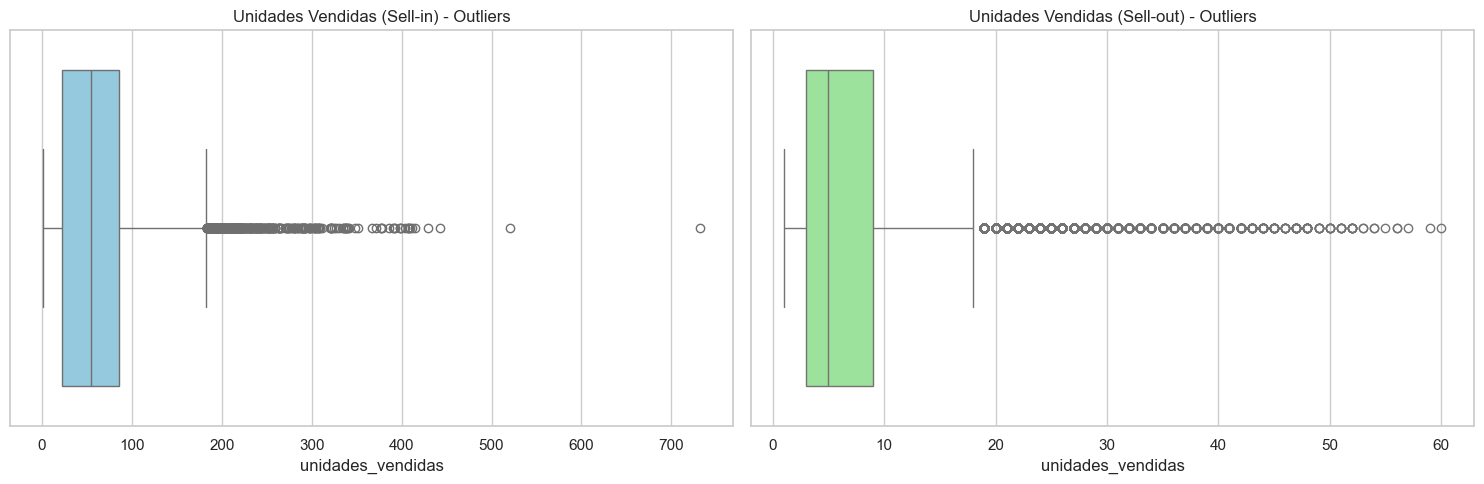

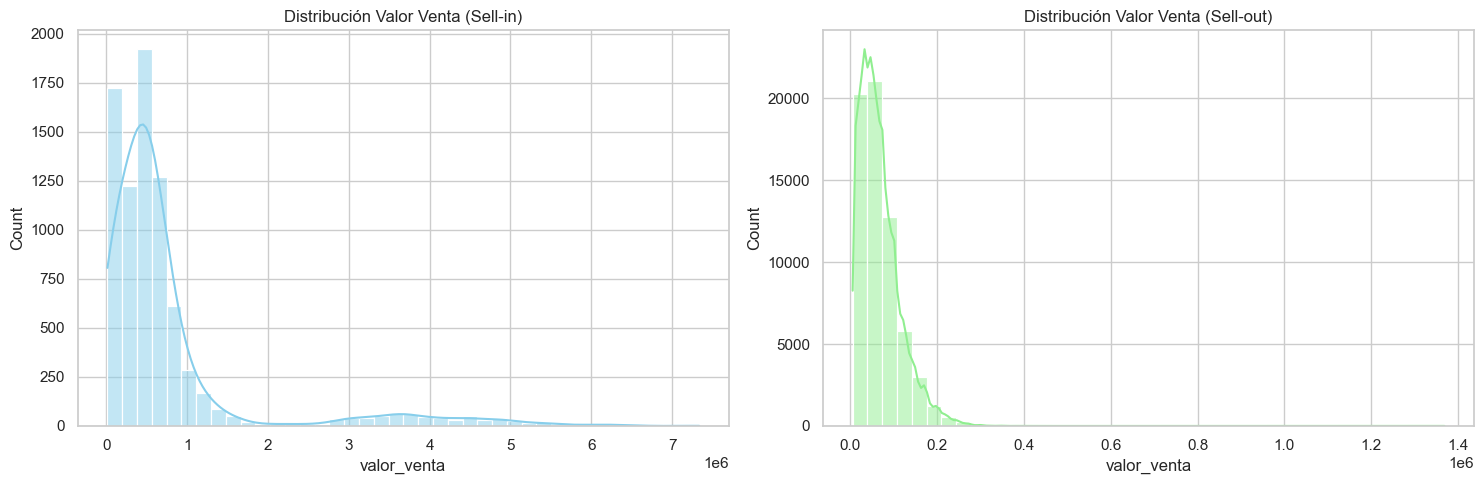

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de seaborn
sns.set_theme(style="whitegrid")

# Convertimos columnas a numéricas forzando errores a NaN para evitar choques con el string 'N/A'
sell_in_num = Consolidado_sell_in[['unidades_vendidas', 'valor_venta', 'kilos_vendidos']].apply(pd.to_numeric, errors='coerce')
sell_out_num = Consolidado_sell_out[['unidades_vendidas', 'valor_venta', 'kilos_vendidos']].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=sell_in_num, x='unidades_vendidas', ax=axes[0], color='skyblue')
axes[0].set_title('Unidades Vendidas (Sell-in) - Outliers')
sns.boxplot(data=sell_out_num, x='unidades_vendidas', ax=axes[1], color='lightgreen')
axes[1].set_title('Unidades Vendidas (Sell-out) - Outliers')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(sell_in_num['valor_venta'].dropna(), bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Valor Venta (Sell-in)')
sns.histplot(sell_out_num['valor_venta'].dropna(), bins=40, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución Valor Venta (Sell-out)')
plt.tight_layout()
plt.show()

**Recomendaciones para tu Interpretación:**
- **Diagramas de Caja (Outliers):** Aquellos puntos individuales saliendo de la barra representan atípicos. Son pedidos excepcionales o anomalías de digitación (ej: alguien tipea 10.000 unidades en vez de 10). Depende del negocio si debes cortarlos.
- **Histogramas:** La mayoría de ingresos de consumo masivo están ladeados a la izquierda (muchos valores pequeños). Si descubres que los gráficos están totalmente aplastados y no dejan ver curvas de campana, los outliers extremos están opacando tu visibilidad y deberías filtrarlos en gráficas futuras limitando el eje.

### 3. Limpieza y Transformaciones Necesarias

In [26]:
if 'fecha_factura' in Consolidado_sell_in.columns:
    Consolidado_sell_in['fecha_factura'] = pd.to_datetime(Consolidado_sell_in['fecha_factura'], format='%d/%m/%Y', errors='coerce')
    Consolidado_sell_in['Mes'] = Consolidado_sell_in['fecha_factura'].dt.to_period('M')

if 'fecha_factura' in Consolidado_sell_out.columns:
    Consolidado_sell_out['fecha_factura'] = pd.to_datetime(Consolidado_sell_out['fecha_factura'], format='%d/%m/%Y', errors='coerce')
    Consolidado_sell_out['Mes'] = Consolidado_sell_out['fecha_factura'].dt.to_period('M')

# Unir transacciones con los maestros
sell_in_full = Consolidado_sell_in.merge(maestro_clientes, left_on='cliente_id', right_on='cliente_id', how='left') \
                      .merge(maestro_productos, left_on='sku', right_on='sku', how='left')

sell_out_full = Consolidado_sell_out.merge(maestro_clientes, left_on='cliente_id', right_on='cliente_id', how='left') \
                        .merge(maestro_productos, left_on='sku', right_on='sku', how='left')

# Transformar para consolidado
sell_in_full['Tipo_Transaccion'] = 'Sell-In'
sell_in_full = sell_in_full.rename(columns={'unidades_vendidas': 'Unidades'})

sell_out_full['Tipo_Transaccion'] = 'Sell-Out'
sell_out_full = sell_out_full.rename(columns={'unidades_vendidas': 'Unidades'})



# Preparar consolidado final
consolidado = pd.concat([sell_in_full, sell_out_full], ignore_index=True)


In [27]:
consolidado


,fecha_factura,trimestre,cliente_id,sku,Unidades,kilos_vendidos,kilos_vendidos_calculados,valor_venta,responsable_comercial,comentario,archivo_origen,Mes,cliente,canal,regional,zona,ciudad,formato_cliente,descripcion_producto,peso_kg,unidad,variedad,subcategoria,categoria,tipo_producto,marca,origen,Tipo_Transaccion,semestre
0,2025-01-01,1.0,C017,900101,2,0.16,0.16,15270,Daniel Rojas,N/A,ERP_COMERCIAL_Q1,2025-01,RapiExpress,E-commerce,Centro,Bogotá y Sabana,Bogotá,Quick Commerce,SALAMI TAJADO CASA IBERIA 80G,0.08,UND,SALAMI,CHARCUTERIA,CARNES MADURADAS,regular,CASA IBERIA,IMPORTADO,Sell-In,NaN
1,2025-01-01,1.0,C017,110108,2,0.3,0.3,23540,Laura Mejía,N/A,ERP_COMERCIAL_Q1,2025-01,RapiExpress,E-commerce,Centro,Bogotá y Sabana,Bogotá,Quick Commerce,MANCHEGO CUÑA MONTE AZUL 150G,0.15,UND,MANCHEGO,CUÑAS PREMIUM,QUESOS MADURADOS,regular,MONTE AZUL,IMPORTADO,Sell-In,NaN
2,2025-01-01,1.0,C017,900103,3,0.24,0.24,24940,Laura Mejía,N/A,ERP_COMERCIAL_Q1,2025-01,RapiExpress,E-commerce,Centro,Bogotá y Sabana,Bogotá,Quick Commerce,JAMON SERRANO TAJADO CASA IBERIA 80G,0.08,UND,JAMON SERRANO,CHARCUTERIA,CARNES MADURADAS,regular,CASA IBERIA,IMPORTADO,Sell-In,NaN
3,2025-01-03,1.0,C017,110113,2,0.5,0.5,23820,Laura Mejía,N/A,ERP_COMERCIAL_Q1,2025-01,RapiExpress,E-commerce,Centro,Bogotá y Sabana,Bogotá,Quick Commerce,PARMESANO RALLADO ORO LECHE 250G,0.25,UND,TIPO PARMESANO,RALLADOS,QUESO PARMESANO,regular,ORO LECHE,MAQUILA,Sell-In,NaN
4,2025-01-03,1.0,C017,300102,3,N/A,0.69,22130,Daniel Rojas,N/A,ERP_COMERCIAL_Q1,2025-01,RapiExpress,E-commerce,Centro,Bogotá y Sabana,Bogotá,Quick Commerce,JAMON DE PAVO FINAS LONCHAS SIERRA CARNES 230G,0.23,UND,JAMON PAVO,LONCHAS,CARNES FRIAS,regular,SIERRA CARNES,NACIONAL,Sell-In,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72940,2025-09-12,NaN,C003,110114,4,1.0,1.0,99000,NaN,NaN,POS_SHARE_H2,2025-09,MaxiCompra Caribe,Grandes Superficies,Caribe,Costa Norte,Barranquilla,Supermercado,GOUDA NATURAL CUÑA LOMA DORADA 250G,0.25,UND,GOUDA NATURAL,CUÑAS,QUESOS MADURADOS,regular,LOMA DORADA,IMPORTADO,Sell-Out,2.0
72941,2025-09-16,NaN,C001,130101,8,1.2,1.2,46610,NaN,NaN,POS_SHARE_H2,2025-09,HiperMax Nacional,Grandes Superficies,Centro,Bogotá y Sabana,Bogotá,Hipermercado,CHEDDAR ESTILO AMERICANO DELILAT 150G,0.15,UND,CHEDDAR ANALOGO,LONCHAS,QUESOS ANALOGOS,regular,DELILAT,MAQUILA,Sell-Out,2.0
72942,2025-08-15,NaN,C015,300101,1,0.23,0.23,8590,NaN,NaN,POS_SHARE_H2,2025-08,Abarrotes Norte,Tradicional Modernizado,Caribe,Costa Norte,Barranquilla,Supermercado Regional,JAMON DE CERDO FINAS LONCHAS SIERRA CARNES 230G,0.23,UND,JAMON CERDO,LONCHAS,CARNES FRIAS,regular,SIERRA CARNES,NACIONAL,Sell-Out,2.0
72943,2025-10-17,NaN,C014,120101,18,4.5,4.5,185760,NaN,NaN,POS_SHARE_H2,2025-10,Plaza Hogar,Grandes Superficies,Occidente,Valle del Cauca,Cali,Hipermercado,MOZZARELLA TAJADA CAMPOCLARO 250G,0.25,UND,MOZZARELLA,QUESOS TAJADOS,QUESOS FRESCOS,regular,CAMPOCLARO,NACIONAL,Sell-Out,2.0


### 4. Cálculo de Métricas Clave (Inventario, DOH, % Presupuesto)

In [28]:
inventario_inicial

,fecha_corte,cliente_id,sku,unidades_inventario,kilos_inventario,kilos_calculados
0,2024-12-31,C001,110101,97,14.55,14.55
1,2024-12-31,C001,110102,87,13.05,13.05
2,2024-12-31,C001,110103,102,15.30,15.30
3,2024-12-31,C001,110104,84,12.60,12.60
4,2024-12-31,C001,110105,88,13.20,13.20
...,...,...,...,...,...,...
217,2024-12-31,C018,900102,93,7.44,7.44
218,2024-12-31,C017,300102,4,0.92,0.92
219,2024-12-31,C003,110112,120,12.00,12.00
220,2024-12-31,C002,900102,86,6.88,6.88


In [29]:
# Cálculo del Inventario por cliente y producto a nivel mensual
# Supuesto: Inventario_Mes = Inventario_Mes_Anterior + Sell_In - Sell_Out

resumen_mensual = consolidado.groupby(['Mes', 'cliente_id', 'sku', 'Tipo_Transaccion'])['Unidades'].sum().unstack(fill_value=0).reset_index()

if 'Sell-In' not in resumen_mensual.columns:
    resumen_mensual['Sell-In'] = 0
if 'Sell-Out' not in resumen_mensual.columns:
    resumen_mensual['Sell-Out'] = 0

# Renombrar columnas para facilitar el cálculo
resumen_mensual.rename(columns={'Sell-In': 'Unidades_Sell_In', 'Sell-Out': 'Unidades_Sell_Out'}, inplace=True)

inventario_inicial_base = inventario_inicial.copy()
inventario_inicial_base['Mes'] = pd.Period('2024-12', 'M') # Periodo previo a Enero 2025

# Lógica iterativa
resumen_mensual = resumen_mensual.sort_values(by=['cliente_id', 'sku', 'Mes'])
resumen_mensual['Variacion_Inventario'] = resumen_mensual['Unidades_Sell_In'] - resumen_mensual['Unidades_Sell_Out']

# Calcular Inventario Final acumulativo agrupado por Cliente y SKU + I. Inicial.

# Simulación de DOH (Days on Hand)
# DOH = (Inventario / Sell_Out promedio mensual) * 30
resumen_mensual['DOH'] = np.where(resumen_mensual['Unidades_Sell_Out'] > 0, 
                                  (resumen_mensual['Variacion_Inventario'] / resumen_mensual['Unidades_Sell_Out']) * 30, 
                                  999) # 999 indica sobreinventario si no hay sell-out



In [30]:
# ================================================
# CÁLCULO CORRECTO DE INVENTARIO ACUMULADO
# ================================================

# 1. Agregamos Sell-In y Sell-Out por mes, cliente y sku
ventas_mensuales = consolidado.groupby(['Mes', 'cliente_id', 'sku', 'Tipo_Transaccion'])['Unidades'].sum().unstack(fill_value=0).reset_index()
ventas_mensuales = ventas_mensuales.rename(columns={
    'Sell-In': 'Unidades_Sell_In',
    'Sell-Out': 'Unidades_Sell_Out'
}).fillna(0)

# 2. Inventario inicial (diciembre 2024)
inventario_base = inventario_inicial.copy()
inventario_base = inventario_base.rename(columns={
    'unidades_inventario': 'Unidades_Inicial',
    'kilos_calculados': 'Kilos_Inicial'
})
inventario_base['Mes'] = pd.Period('2024-12', freq='M')

# === NUEVO: Traemos el peso real por SKU desde maestro_productos ===
inventario_base = inventario_base.merge(
    maestro_productos[['sku', 'peso_kg']], 
    on='sku', 
    how='left'
)
inventario_base['peso_kg'] = pd.to_numeric(inventario_base['peso_kg'], errors='coerce').fillna(1)

# Calculamos Kilos_Inicial correctamente usando el peso real
inventario_base['Kilos_Inicial'] = inventario_base['Unidades_Inicial'] * inventario_base['peso_kg']

# 3. Unimos todo
resumen_mensual = pd.merge(
    ventas_mensuales,
    inventario_base[['cliente_id', 'sku', 'Unidades_Inicial', 'Kilos_Inicial', 'peso_kg']],
    on=['cliente_id', 'sku'],
    how='left'
).fillna(0)

resumen_mensual = resumen_mensual.sort_values(by=['cliente_id', 'sku', 'Mes'])

# 4. Cálculo acumulativo CORRECTO
resumen_mensual['Inventario_Anterior'] = 0.0
resumen_mensual['Variacion_Inventario'] = 0.0
resumen_mensual['Unidades_Inventario_Final'] = 0.0
resumen_mensual['Kilos_Inventario_Final'] = 0.0

for (cliente, sku), group in resumen_mensual.groupby(['cliente_id', 'sku']):
    group = group.sort_values('Mes')
    inventario_actual = group.iloc[0]['Unidades_Inicial']
    kilos_actual = group.iloc[0]['Kilos_Inicial']
    peso_sku = group.iloc[0]['peso_kg']   # Peso fijo por SKU (ya traído de maestro_productos)

    for i in range(len(group)):
        idx = group.index[i]
        
        sell_in  = group.iloc[i]['Unidades_Sell_In']
        sell_out = group.iloc[i]['Unidades_Sell_Out']
        
        # Variación del mes en unidades
        variacion_unidades = sell_in - sell_out
        
        # Kilos se calcula con el peso real del SKU
        variacion_kilos = variacion_unidades * peso_sku
        
        # Inventario final del mes
        inventario_final = inventario_actual + variacion_unidades
        kilos_final = kilos_actual + variacion_kilos
        
        # Guardamos
        resumen_mensual.at[idx, 'Inventario_Anterior'] = inventario_actual
        resumen_mensual.at[idx, 'Variacion_Inventario'] = variacion_unidades
        resumen_mensual.at[idx, 'Unidades_Inventario_Final'] = max(0, inventario_final)
        resumen_mensual.at[idx, 'Kilos_Inventario_Final'] = max(0, kilos_final)
        
        # El siguiente mes parte de este final
        inventario_actual = resumen_mensual.at[idx, 'Unidades_Inventario_Final']
        kilos_actual = resumen_mensual.at[idx, 'Kilos_Inventario_Final']

# 5. DOH correcto (ahora basado en unidades, pero puedes cambiarlo a kilos si quieres)
resumen_mensual['DOH'] = np.where(
    resumen_mensual['Unidades_Sell_Out'] > 0,
    (resumen_mensual['Unidades_Inventario_Final'] / resumen_mensual['Unidades_Sell_Out']) * 30,
    999
)

# 6. Estado de abastecimiento
resumen_mensual['Estado_Abastecimiento'] = np.select(
    [
        resumen_mensual['DOH'] < 1,
        (resumen_mensual['DOH'] >= 1) & (resumen_mensual['DOH'] <= 7),
        resumen_mensual['DOH'] > 7
    ],
    ['🔴 Falta', '🟢 Bien', '🟡 Sobre'],
    default='🟢 Bien'
)

# === ELIMINAMOS LA COLUMNA peso_kg (solo se usó para el cálculo interno) ===
resumen_mensual = resumen_mensual.drop(columns=['peso_kg'], errors='ignore')

print("✅ Inventario acumulado calculado correctamente con peso real por SKU (maestro_productos)")
print("   → Columna 'peso_kg' eliminada de los valores finales")

✅ Inventario acumulado calculado correctamente con peso real por SKU (maestro_productos)
   → Columna 'peso_kg' eliminada de los valores finales


In [31]:
resumen_mensual

,Mes,cliente_id,sku,Unidades_Sell_In,Unidades_Sell_Out,Unidades_Inicial,Kilos_Inicial,Inventario_Anterior,Variacion_Inventario,Unidades_Inventario_Final,Kilos_Inventario_Final,DOH,Estado_Abastecimiento
0,2025-01,C001,110101,126,183,97.0,14.55,97.0,-57.0,40.0,6.00,6.557377,🟢 Bien
257,2025-02,C001,110101,154,158,97.0,14.55,40.0,-4.0,36.0,5.40,6.835443,🟢 Bien
516,2025-03,C001,110101,206,167,97.0,14.55,36.0,39.0,75.0,11.25,13.473054,🟡 Sobre
771,2025-04,C001,110101,259,176,97.0,14.55,75.0,83.0,158.0,23.70,26.931818,🟡 Sobre
1031,2025-05,C001,110101,144,186,97.0,14.55,158.0,-42.0,116.0,17.40,18.709677,🟡 Sobre
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,2025-08,C018,900102,249,227,93.0,7.44,64.0,22.0,86.0,6.88,11.365639,🟡 Sobre
2327,2025-09,C018,900102,212,247,93.0,7.44,86.0,-35.0,51.0,4.08,6.194332,🟢 Bien
2597,2025-10,C018,900102,224,224,93.0,7.44,51.0,0.0,51.0,4.08,6.830357,🟢 Bien
2868,2025-11,C018,900102,277,245,93.0,7.44,51.0,32.0,83.0,6.64,10.163265,🟡 Sobre


In [32]:
consolidado["regional"].unique()

array(['Centro', 'Caribe', 'Occidente', 'Santanderes', 'Antioquia',
       'Internacional'], dtype=object)

In [33]:
consolidado[consolidado["regional"]=="Internacional"]["Tipo_Transaccion"].unique()

array(['Sell-In'], dtype=object)

### 5. Guardado del Archivo Consolidado Final

In [34]:

import os
import pyarrow as pa

# Desatascamos la memoria de PyArrow por si corres la celda varias veces
try:
    pa.unregister_extension_type("pandas.period")
except Exception:
    pass

# 1. Convertimos la columna de "Mes" a texto en las tablas donde existe
if 'Mes' in Consolidado_sell_in.columns:
    Consolidado_sell_in['Mes'] = Consolidado_sell_in['Mes'].astype(str)
if 'Mes' in Consolidado_sell_out.columns:
    Consolidado_sell_out['Mes'] = Consolidado_sell_out['Mes'].astype(str)
if 'Mes' in resumen_mensual.columns:
    resumen_mensual['Mes'] = resumen_mensual['Mes'].astype(str)

# 2. Exportamos normalmente
os.makedirs('datos_limpios', exist_ok=True)

Consolidado_sell_in.to_csv('datos_limpios/consolidado_sell_in.csv', index=False)
Consolidado_sell_out.to_csv('datos_limpios/consolidado_sell_out.csv', index=False)
resumen_mensual.to_csv('datos_limpios/resumen_mensual.csv', index=False)
maestro_clientes.to_csv('datos_limpios/maestro_clientes.csv', index=False)
maestro_productos.to_csv('datos_limpios/maestro_productos.csv', index=False)
mercado.to_csv('datos_limpios/mercado.csv', index=False)
inventario_inicial.to_csv('datos_limpios/inventario_inicial.csv', index=False)
presupuesto.to_csv('datos_limpios/presupuesto.csv', index=False)

print("¡Exportación Exitosa Libre de Errores!")

¡Exportación Exitosa Libre de Errores!
